# 06 Baseline Models

## Purpose
Train baseline models before advanced models, as required by the project guidelines. The first target is future hospitalization risk.

## Imports

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_DIR = OUTPUTS_DIR / "figures"
TABLES_DIR = OUTPUTS_DIR / "tables"
MODELS_DIR = PROJECT_ROOT / "models"
for directory in [FIGURES_DIR, TABLES_DIR, MODELS_DIR, DATA_DIR / "processed"]:
    directory.mkdir(parents=True, exist_ok=True)

import pandas as pd
from sklearn.model_selection import train_test_split

from src.data_cleaning import load_raw_data, clean_all
from src.features import build_patient_features, get_modeling_matrices
from src.modeling import make_baseline_models, fit_models, save_model
from src.evaluation import evaluate_models, save_metrics, plot_roc_curves, plot_confusion_matrix

## Data loading

In [2]:
feature_path = DATA_DIR / "processed" / "modeling_dataset.csv"
if feature_path.exists():
    feature_df = pd.read_csv(feature_path)
else:
    data = clean_all(load_raw_data(DATA_DIR))
    feature_df = build_patient_features(**data)
    feature_df.to_csv(feature_path, index=False)

feature_df.shape

(100000, 99)

## Main modeling

In [3]:
target = "future_hospitalization"
X, y = get_modeling_matrices(feature_df, target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

baseline_models = make_baseline_models(X_train)
fitted_baselines = fit_models(baseline_models, X_train, y_train)
baseline_metrics = evaluate_models(fitted_baselines, X_test, y_test, target)
baseline_metrics

/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow encountere

/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,model,target,accuracy,precision,recall,f1,roc_auc,average_precision
1,logistic_regression,future_hospitalization,0.64548,0.076797,0.616535,0.136581,0.686321,0.087288
0,dummy_most_frequent,future_hospitalization,0.95452,0.000000,0.000000,0.000000,0.500000,0.045480


/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/chinmaynaringrekar/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'Logistic Regression Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>)

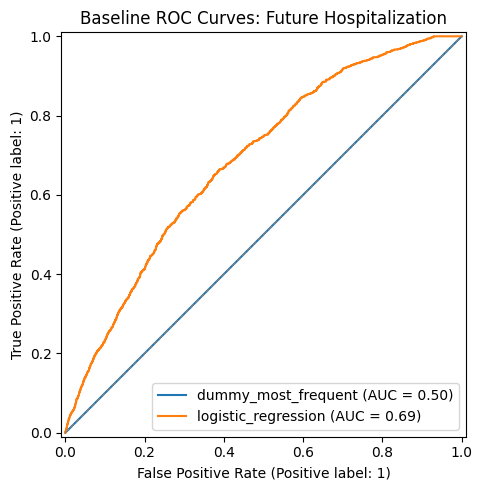

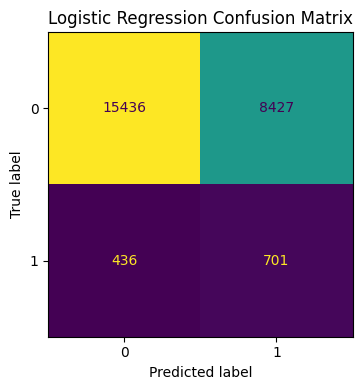

In [4]:
save_metrics(baseline_metrics, TABLES_DIR / "06_baseline_model_metrics.csv")
for name, model in fitted_baselines.items():
    save_model(model, MODELS_DIR / f"{target}_{name}.joblib")

plot_roc_curves(
    fitted_baselines, X_test, y_test,
    title="Baseline ROC Curves: Future Hospitalization",
    path=FIGURES_DIR / "06_baseline_roc_future_hospitalization.png",
)
plot_confusion_matrix(
    fitted_baselines["logistic_regression"], X_test, y_test,
    title="Logistic Regression Confusion Matrix",
    path=FIGURES_DIR / "06_logistic_confusion_matrix.png",
)

## Key findings

- A dummy classifier sets the minimum baseline.
- Logistic regression provides an interpretable statistical baseline.
- Later notebooks compare advanced models against these results.

## Saved outputs

Model artifacts are saved in `models/`, metrics in `outputs/tables/`, and figures in `outputs/figures/`.